# Figure: neural correlates of LD1

The figure of `neural/lda1_neural_summary.ipynb`, redrawn in paper mode with the conventions of the other figures in `figure_generation/` (same type size, shared margins and letters from `fig_layout.py`, statistics block with the FDR q, 180 mm wide). Nothing is recomputed differently: the metric tables are that notebook's cache (`neural/lda1_tables/`, the newest built under the same QC settings), the cohort is `apply_cohort(..., 'common')` and the tests are `lda1_neural_metrics.run_tests` — GLM slope of LD1 with region and trial-count covariates at the neuron (FR, FF) or session × region ($r_{SC}$) level, permutation over sessions (2000), FDR within each metric.

| row | metric |
|---|---|
| a | firing rate |
| b | Fano factor |
| c | noise correlation ($r_{SC}$) |

Columns: time course per LD1 bin (equal-count bins; baseline window grey, post-stimulus window hatched), then one scatter per test (one point per session, mean over its neurons / regions, coloured by LD1). The regression line is drawn only when the test survives FDR; the panel prints the test's own partial r, the session-level permutation p and the FDR q.

Writes `figure_generation/figures/fig_neural.pdf` (for LaTeX) and a dated SVG.

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

REPO = pathlib.Path.cwd().resolve()
while not (REPO / 'Functions' / 'trial_modes.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
PI = REPO / 'paper-individuality'
for p in [PI, PI / 'neural', PI / 'figure_generation']:
    sys.path.insert(0, str(p))
import paper_style as ps
import lda1_neural_metrics as nm
import fig_layout as fl
ps.use('paper')
pd.set_option('display.width', 160)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters — the QC settings of `lda1_neural_summary` (they select which cached tables are read)

In [2]:
FIG = 'fig_neural'
cfg = nm.default_config()
cfg['MIN_FR_HZ'] = 1.0
cfg['FR_FLOOR_REQUIRE'] = 'both'
cfg['FR_FLOOR_SOURCE'] = 'session'
cfg['UNIFORM_FR_FLOOR'] = True
cfg['MIN_PRESENCE_RATIO'] = 0.90
cfg['MIN_NEURONS'] = 15
cfg['MIN_NEURONS_RSC'] = None
N_BINS = 5                    # LD1 bins for the time courses (display only)
PSTH_BINNING = 'quantile'     # equal-count bins, as in lda1_neural_summary
LINE_RULE = 'fdr'             # regression line only for tests that survive FDR
PSTH_XLIM = (-0.3, 0.6)
print('cache:', nm.cache_tag(cfg))

cache: lda1_neural_pr90_fr10_sess


## Data and tests

In [3]:
tables_raw = nm.load_tables(cfg=cfg)
tables = nm.apply_cohort(tables_raw, cfg, 'common')
tsec = tables_raw['time']['tsec'].values
res = nm.run_tests(tables, cfg, predictor='lda_1', verbose=False)
RES = {(r['metric'], r['test']): r for _, r in res.iterrows()}
print(nm.results_table(res, p_floor=1.0 / cfg['N_PERM']))

loaded 'lda1_neural_pr90_fr10_sess_02-10-2026': curves (1886), ff (18196), fr (20624), rsc (624), sessions (244), time (90)
LDA file: mouse_LDA_5_bins_raw_shrink0.5_wmouse_360_02-10-2026
  attached lda_2, lda_3 to the metric tables
cohort 'common': fr 17986 rows / 204 sessions | ff 15824 rows / 204 sessions | rsc 555 rows / 203 sessions


metric            test                          unit       n  n_sess     slope   r_part      BF10      evidence    p_perm  q_metric    q_all   q_Holm      
                                                                                                                         <-- reported         
Firing rate       Baseline                    neuron   17986     204    0.0136   0.0393   9.3e+03     strong H1    0.0450    0.0900   0.0619   0.1350      
Firing rate       Post-stimulus               neuron   17986     204    0.0037   0.0112     0.029     strong H0    0.5185    0.5185   0.5185   0.5185      
Firing rate       Response magnitude          neuron   17986     204    0.0374   0.0132    0.0444     strong H0    0.2555    0.3407   0.2811   0.5110      
Firing rate       Response onset              neuron   13494     204    0.0017   0.0773  2.41e+15     strong H1    0.0030    0.0120   0.0066   0.0120     *
Fano factor       Baseline                    neuron   15824     204   -0.003

## Panels

In [4]:
LINE_COL = {'fdr': 'fdr_sig', 'uncorrected': 'significant'}[LINE_RULE]
P_FLOOR = 1.0 / cfg['N_PERM']
# short y labels: the row (metric) and the column title already say what is plotted
Y_LABEL = {('Firing rate', 'Baseline'): 'Rate (Hz)', ('Firing rate', 'Post-stimulus'): 'Rate (Hz)',
           ('Firing rate', 'Response magnitude'): 'Post − pre (Hz)', ('Firing rate', 'Response onset'): 'Onset (s)',
           ('Fano factor', 'Baseline'): 'FF', ('Fano factor', 'Post-stimulus'): 'FF',
           ('Fano factor', 'Response magnitude'): 'Pre − post', ('Fano factor', 'Response onset'): 'Quench onset (s)',
           ('Noise correlation', 'Baseline'): '$r_{SC}$', ('Noise correlation', 'Post-stimulus'): '$r_{SC}$',
           ('Noise correlation', 'Response magnitude'): 'Pre − post'}
COL_TITLE = {'PSTH': 'Time course', 'Baseline': 'Baseline', 'Post-stimulus': 'Post-stimulus',
             'Response magnitude': 'Response\nmagnitude', 'Response onset': 'Response onset'}

def psth_panel(ax, metric, name_windows=False):
    # descriptive time course per LD1 bin, mean +/- SEM across sessions (regions averaged within session first)
    key, ylabel, ref, pre_key, post_key = nm.PSTH_ROWS[metric]
    pre, post = cfg[pre_key], cfg[post_key]
    ax.axvspan(*pre, facecolor=ps.NEUTRAL, alpha=0.2, lw=0, zorder=0)
    ax.axvspan(*post, facecolor='none', edgecolor=ps.NEUTRAL, hatch='////', lw=0, alpha=0.6, zorder=0)
    agg, edges = nm.bin_curves(tables['curves'], key, n_bins=N_BINS, return_edges=True, binning=PSTH_BINNING,
                               predictor='lda_1')
    colors = ps.LD1_CMAP(np.linspace(0, 1, N_BINS))
    xmask = (tsec >= PSTH_XLIM[0]) & (tsec <= PSTH_XLIM[1])
    span = []
    for b in sorted(agg):
        M = agg[b]
        mean = np.nanmean(M, axis=0)
        ax.plot(tsec, mean, color=colors[b], lw=1.0)
        if M.shape[0] > 1:
            sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
            ax.fill_between(tsec, mean - sem, mean + sem, color=colors[b], alpha=0.3, lw=0)
            span += [(mean - sem)[xmask], (mean + sem)[xmask]]
    ax.axvline(0, color='k', ls='--', lw=0.5, alpha=0.5, zorder=1)
    ax.set_xlim(PSTH_XLIM)
    v = np.concatenate(span); lo, hi = np.nanmin(v), np.nanmax(v); pad = 0.06 * (hi - lo)
    ax.set_ylim(lo - pad, hi + pad)
    if ref is not None and lo - pad <= ref <= hi + pad:
        ax.axhline(ref, color='0.5', ls=':', lw=0.6, zorder=1)
    if name_windows:
        for w, nmame in ((pre, 'base'), (post, 'post')):
            ax.text(np.mean(w), 1.01, nmame, transform=ax.get_xaxis_transform(), ha='center', va='bottom',
                    fontsize=plt.rcParams['font.size'] * 0.7, color='0.35')
    ax.set_xlabel('Time from stim. (s)')
    ax.set_ylabel(ylabel)
    ax.set_box_aspect(1)
    return edges, {b: agg[b].shape[0] for b in agg}

def scatter_panel(ax, r):
    # one point per session (mean of its neurons / regions), coloured by LD1; statistics are the test's own
    tbl = tables[r['table']]
    d = tbl.groupby('session').agg(y=(r['display_col'], 'mean'), ld=('lda_1', 'first')).dropna()
    x, y = d['ld'].values, d['y'].values
    ax.scatter(x, y, c=ps.ld1_colors(x), s=5, alpha=0.85, edgecolors='none')
    ps.regline(ax, x, y, bool(r[LINE_COL]))
    ax.set_xlabel('LD1')
    ax.set_ylabel(Y_LABEL.get((r['metric'], r['test']), r['ylabel']))
    ax.set_box_aspect(1)
    fl.stats_auto(ax, x, y, r['r_partial'], r['p_perm'], int(r['n']), q=r['q_fdr_metric'], p_floor=P_FLOOR)

def blank_panel(ax, why):
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_box_aspect(1)
    ax.text(0.5, 0.5, why, transform=ax.transAxes, ha='center', va='center',
            fontsize=plt.rcParams['font.size'] * 0.8, color='0.55')

def draw_row(fig, spec, metric, top=False):
    g = spec.subgridspec(1, len(nm.FIG_COLS), wspace=0.7)
    axes = []
    for j, col in enumerate(nm.FIG_COLS):
        ax = fig.add_subplot(g[j]); axes.append(ax)
        if col == 'PSTH':
            out = psth_panel(ax, metric, name_windows=top)
        elif (metric, col) in RES:
            scatter_panel(ax, RES[(metric, col)])
        else:
            blank_panel(ax, 'no onset\nmetric')
        if top:
            ax.set_title(COL_TITLE[col], fontsize=plt.rcParams['font.size'],
                         pad=plt.rcParams['axes.titlepad'] * (3 if col == 'PSTH' else 1))
    return axes, out

def draw_legend(fig, spec, edges, counts):
    ax = fig.add_subplot(spec); ax.set_axis_off()
    colors = ps.LD1_CMAP(np.linspace(0, 1, N_BINS))
    h = [Line2D([], [], color=colors[b], lw=1.4, label=f'{edges[b][0]:.1f} to {edges[b][1]:.1f} (n = {counts[b]})')
         for b in sorted(edges)]
    h += [Patch(facecolor=ps.NEUTRAL, alpha=0.2, label='baseline window'),
          Patch(facecolor='none', edgecolor=ps.NEUTRAL, hatch='////', label='post-stimulus window')]
    ax.legend(handles=h, ncol=4, frameon=False, loc='center', title='LD1 bin (time courses), sessions',
              fontsize=plt.rcParams['legend.fontsize'] * 0.9, title_fontsize=plt.rcParams['legend.fontsize'] * 0.9,
              handlelength=1.4, columnspacing=1.2)
    return [ax]

## The assembled figure

180 mm wide; rows a–c are the three metrics, columns as in `lda1_neural_summary`. Writes `figure_generation/figures/fig_neural.pdf` and a dated SVG.

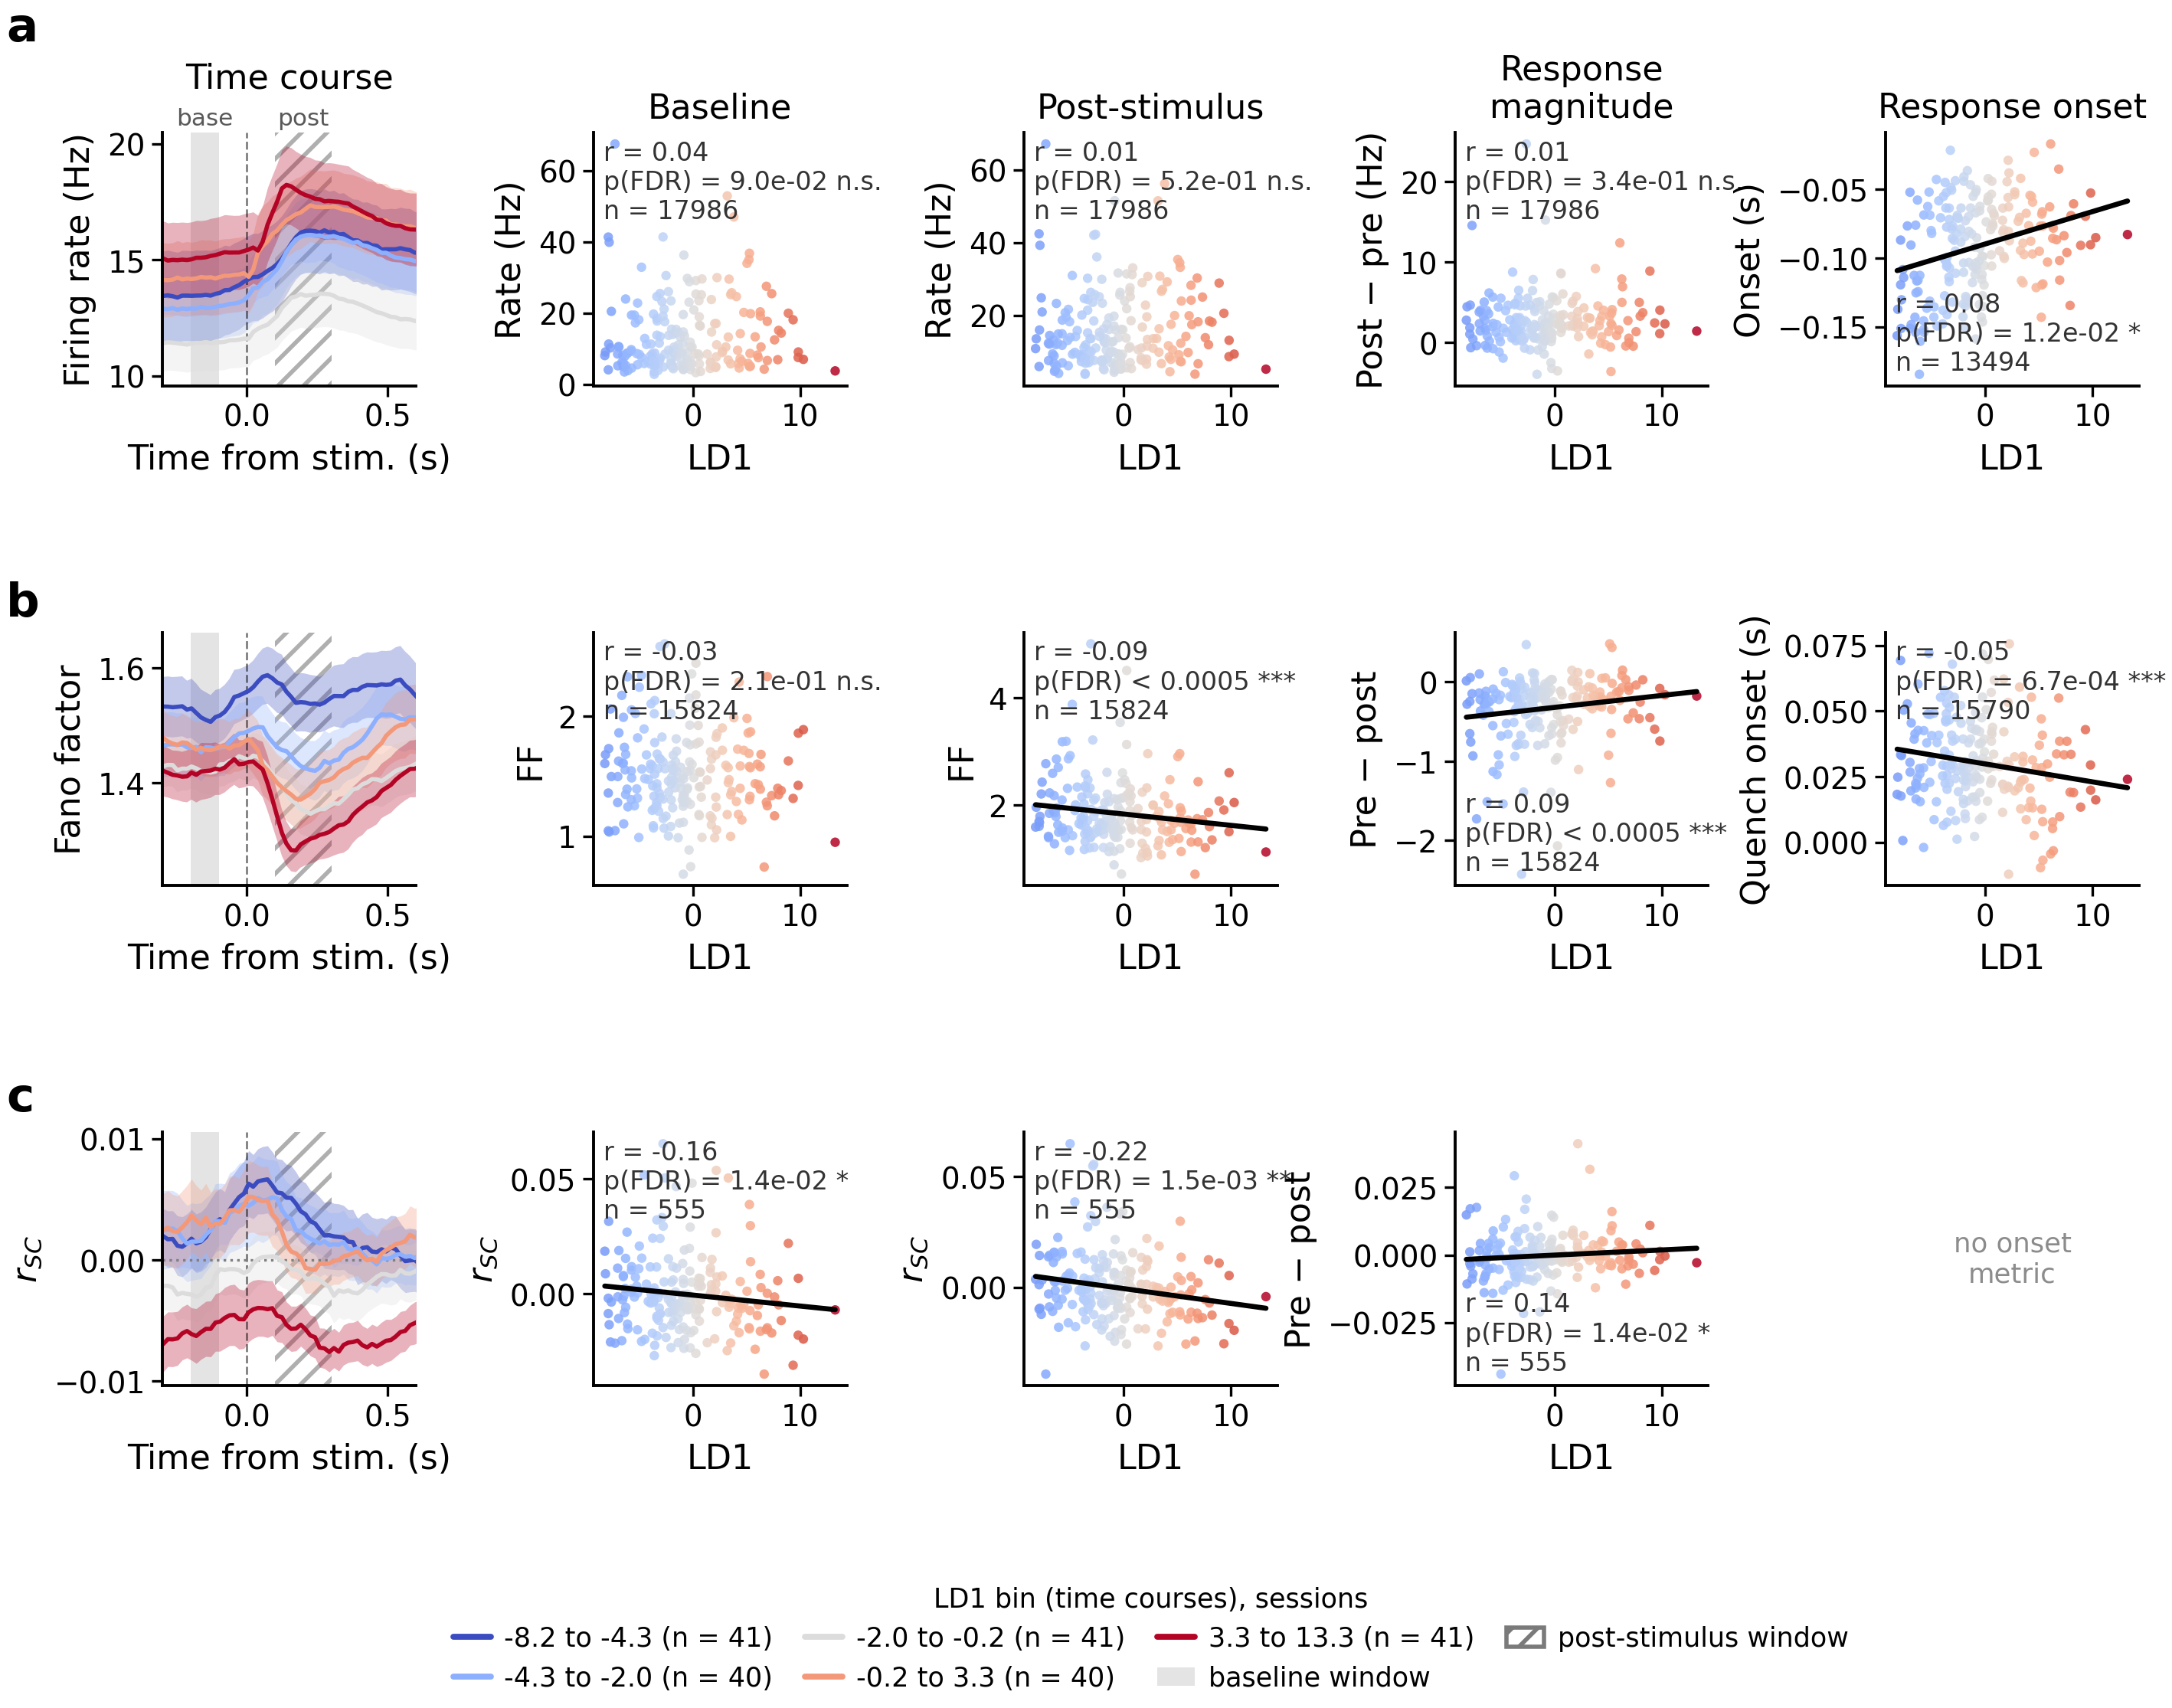

wrote figure_generation/figures/fig_neural_08-10-2026.svg


wrote figure_generation/figures/fig_neural.pdf


In [5]:
from datetime import date
FIG_H = 5.6
fig = plt.figure(figsize=(fl.FIG_WIDTH, FIG_H))
outer = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 0.32], hspace=fl.ROW_HSPACE + 0.12, **fl.MARGINS)
panels, rows = {}, {}
for i, metric in enumerate(nm.METRIC_ROWS):
    axes, (edges, counts) = draw_row(fig, outer[i], metric, top=(i == 0))
    panels['ABC'[i]] = axes
draw_legend(fig, outer[3], edges, counts)
fl.align_left(fig, [panels[k][0] for k in 'ABC'])
fl.place_letters(fig, panels, rows=['A', 'B', 'C'], left='ABC')
plt.show()

OUT_DIR = PI / 'figure_generation' / 'figures'
OUT_DIR.mkdir(exist_ok=True)
for path in [OUT_DIR / f"{FIG}_{date.today().strftime('%d-%m-%Y')}.svg", OUT_DIR / f'{FIG}.pdf']:
    fig.savefig(path)
    print('wrote', path.relative_to(PI))